In [1]:
!pip install ultralytics roboflow

In [2]:
!pip install roboflow
from roboflow import Roboflow

rf = Roboflow(api_key="UcWdjJHn1W7CpumCLhUt")
project = rf.workspace("nurmas-workspace-bscju").project("kelapa-iosh6")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to kelapa-1 in yolov8:: 100%|██████████| 386/386 [00:00<00:00, 8333.17it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
import os

dataset_path = dataset.location
print("📁 Dataset path:", dataset_path)
print("\n📂 Isi folder:")
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for file in files[:5]:
            print(f'{subindent}{file}')

📁 Dataset path: /content/kelapa-1

📂 Isi folder:
kelapa-1/
  data.yaml
  README.roboflow.txt
  train/
    images/
    labels/


In [7]:
import yaml

data_yaml_path = f"{dataset.location}/data.yaml"

with open(data_yaml_path, 'r') as f:
    data_yaml_content = yaml.safe_load(f)

print("Isi dari data.yaml:")
print(yaml.dump(data_yaml_content, default_flow_style=False))

Isi dari data.yaml:
names:
- kelapa
nc: 1
roboflow:
  license: Private
  project: kelapa-iosh6
  url: https://app.roboflow.com/nurmas-workspace-bscju/kelapa-iosh6/1
  version: 1
  workspace: nurmas-workspace-bscju
test: ../test/images
train: ../train/images
val: ../valid/images



In [8]:
# Memperbaiki path di data.yaml
data_yaml_content['train'] = 'train/images'
data_yaml_content['val'] = 'train/images'
data_yaml_content['test'] = 'train/images'

# Menulis kembali file data.yaml dengan path yang diperbarui
with open(data_yaml_path, 'w') as f:
    yaml.dump(data_yaml_content, f)

print("✅ data.yaml telah diperbarui.")
print("Isi data.yaml yang baru:")
print(yaml.dump(data_yaml_content, default_flow_style=False))

✅ data.yaml telah diperbarui.
Isi data.yaml yang baru:
names:
- kelapa
nc: 1
roboflow:
  license: Private
  project: kelapa-iosh6
  url: https://app.roboflow.com/nurmas-workspace-bscju/kelapa-iosh6/1
  version: 1
  workspace: nurmas-workspace-bscju
test: train/images
train: train/images
val: train/images



In [9]:
# TRAIN ULANG
from ultralytics import YOLO

# Load model YOLOv8 pretrained (mulai dari nano untuk cepat)
model = YOLO('yolov8n.pt')  # n=nano, s=small, m=medium

# Training
results = model.train(
    data=f"{dataset.location}/data.yaml",  # path ke dataset
    epochs=100,          # jumlah epoch (bisa naik ke 150-200)
    imgsz=640,           # ukuran gambar
    batch=16,            # batch size (turunkan ke 8 jika RAM penuh)
    name='kelapa_detector',  # nama project
    patience=20,         # early stopping
    save=True,
    plots=True           # simpan grafik training
)

print("✅ Training selesai!")
print(f"📊 Best mAP50: {results.results_dict.get('metrics/mAP50(B)', 'N/A')}")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/kelapa-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=kelapa_detector-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Path to the directory where training results are saved
results_dir = '/content/runs/detect/kelapa_detector-2' # This name is from the previous training output

print(f"Isi dari folder hasil training ({results_dir}):")
for root, dirs, files in os.walk(results_dir):
    for file in files:
        print(os.path.join(root, file))


Berdasarkan isi folder, kita bisa melihat beberapa plot visualisasi. Mari kita tampilkan beberapa plot penting seperti `confusion_matrix.png`, `F1_curve.png`, dan `PR_curve.png`.

Re-running visualization cell...


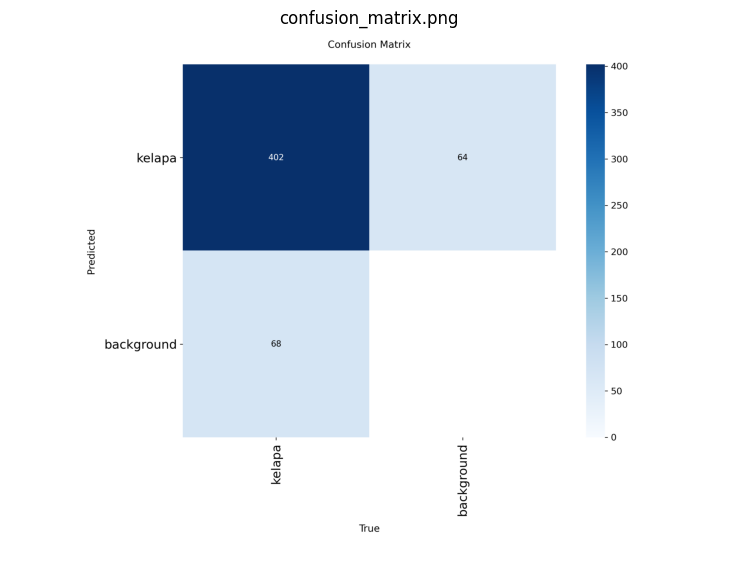

File tidak ditemukan: /content/runs/detect/kelapa_detector-2/F1_curve.png
File tidak ditemukan: /content/runs/detect/kelapa_detector-2/PR_curve.png


In [12]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

print("Re-running visualization cell...")

# Path to the directory where training results are saved
results_dir = '/content/runs/detect/kelapa_detector-2' # This name is from the previous training output

plot_files = [
    os.path.join(results_dir, 'confusion_matrix.png'),
    os.path.join(results_dir, 'F1_curve.png'),
    os.path.join(results_dir, 'PR_curve.png')
]

for plot_file in plot_files:
    if os.path.exists(plot_file):
        img = mpimg.imread(plot_file)
        plt.figure(figsize=(10, 7))
        plt.imshow(img)
        plt.title(os.path.basename(plot_file))
        plt.axis('off')
        plt.show()
    else:
        print(f"File tidak ditemukan: {plot_file}")

In [14]:
# Cell 5 - Validasi model terbaik
from ultralytics import YOLO

# Load model terbaik hasil training
best_model = YOLO('/content/runs/detect/kelapa_detector-2/weights/best.pt')

# Validasi
metrics = best_model.val()
print("📈 Hasil Evaluasi:")
print(f"  mAP50    : {metrics.box.map50:.4f}")
print(f"  mAP50-95 : {metrics.box.map:.4f}")
print(f"  Precision: {metrics.box.mp:.4f}")
print(f"  Recall   : {metrics.box.mr:.4f}")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 638.9±264.1 MB/s, size: 11.8 KB)
val: Scanning /content/kelapa-1/train/labels.cache... 192 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 192/192 47.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 3.7it/s 3.2s
                   all        192        470      0.975      0.802      0.902      0.759
Speed: 3.4ms preprocess, 4.2ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /content/runs/detect/val
📈 Hasil Evaluasi:
  mAP50    : 0.9020
  mAP50-95 : 0.7590
  Precision: 0.9753
  Recall   : 0.8021



image 1/1 /content/kelapa-1/train/images/Screenshot-1247-_png.rf.698ad35b65fd3e7fae980c887b5d4924.jpg: 640x640 1 kelapa, 8.6ms
Speed: 2.3ms preprocess, 8.6ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


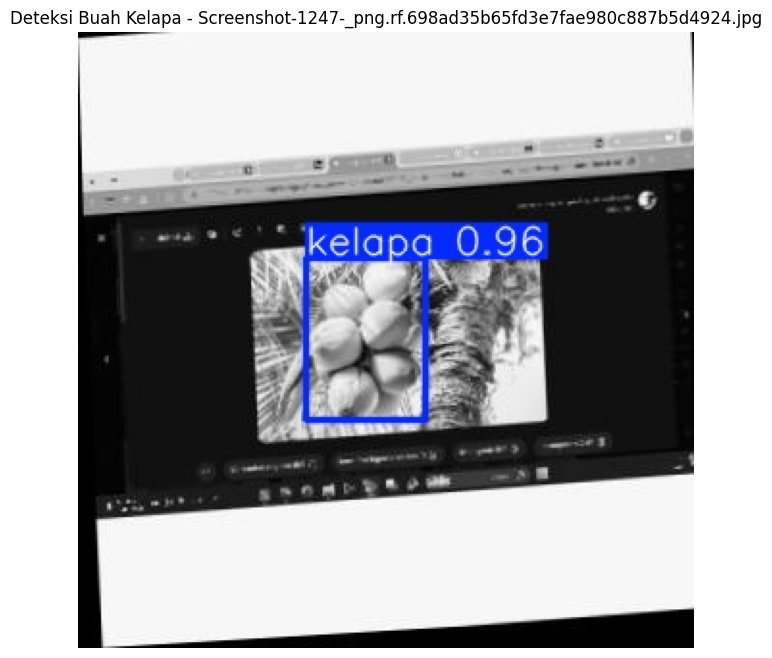


image 1/1 /content/kelapa-1/train/images/pexels-leiliane-dutra-1841922-35788125_jpg.rf.f17e1c17ed3af09f3468008d82ca8e81.jpg: 640x640 1 kelapa, 10.3ms
Speed: 3.3ms preprocess, 10.3ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


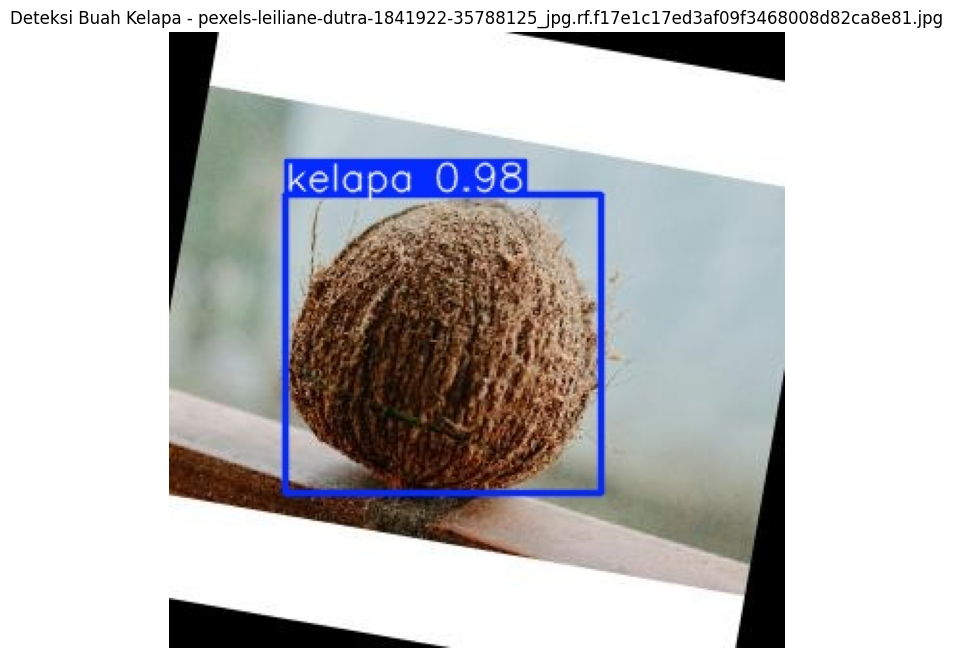


image 1/1 /content/kelapa-1/train/images/pexels-italoguimas-36629021-1-_jpg.rf.2378e850f4e70d5cdead02d724b78b8a.jpg: 640x640 1 kelapa, 10.1ms
Speed: 2.6ms preprocess, 10.1ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


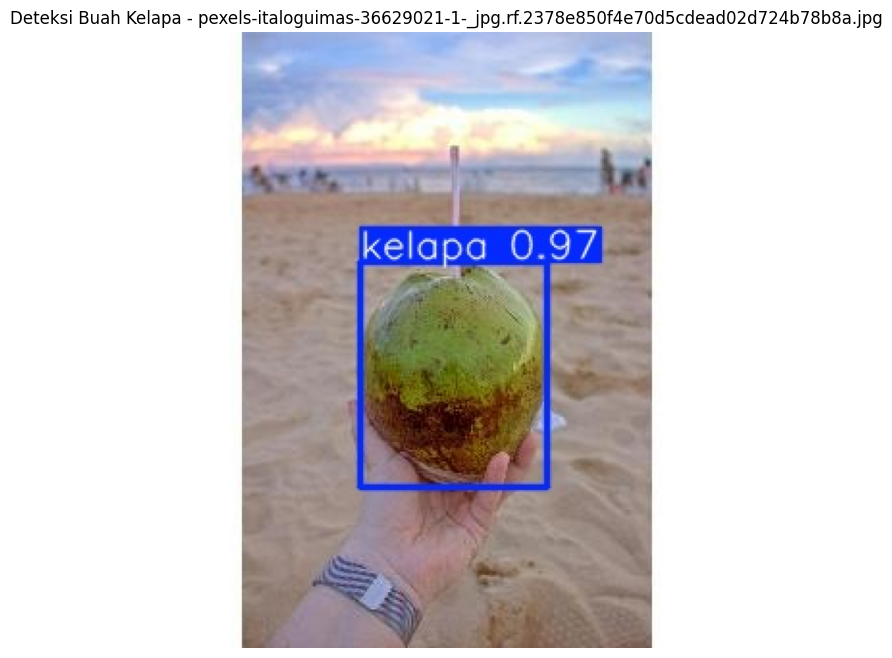

In [15]:
# Cell 6 - Test prediksi
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import glob
import os

best_model = YOLO('/content/runs/detect/kelapa_detector-2/weights/best.pt')

# Test dengan gambar dari dataset training (karena valid/test diarahkan ke train)
train_images = glob.glob(f"{dataset.location}/train/images/*.jpg")[:3]

for img_path in train_images:
    results = best_model.predict(
        source=img_path,
        conf=0.25,       # confidence threshold
        save=True,
        show_labels=True,
        show_conf=True
    )

    # The 'results' object contains the paths to the saved images.
    # We need to get the actual path of the image with detections.
    # The predict method saves results to 'runs/detect/predict*/'.
    # We'll assume the latest run and the first result for display.
    predicted_image_path = results[0].save_dir + '/' + os.path.basename(img_path)

    # Tampilkan hasil
    img = Image.open(predicted_image_path)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(f"Deteksi Buah Kelapa - {os.path.basename(img_path)}")
    plt.axis('off')
    plt.show()

In [16]:
# Cell 7 - Download model ke komputer Anda
from google.colab import files
import shutil

# Zip folder hasil training
shutil.make_archive('kelapa_model', 'zip', '/content/runs/detect/kelapa_detector-2')

# Download
files.download('kelapa_model.zip')
print("✅ Model berhasil didownload!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Model berhasil didownload!
